In [13]:
import numpy as np
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

# 小数第３位
%precision 3

# ランダムシードの固定
np.random.seed(0)

In [14]:
# さいころがとりうる値を配列に格納
dice_data = np.array([1, 2, 3, 4, 5, 6])

In [15]:
# 引数は、対象データ dice_dataから１つランダムに抽出するという意味
print('1つだけランダムに抽出:', np.random.choice(dice_data, 1))

1つだけランダムに抽出: [5]


In [16]:
# さいころを１０００回振る
calc_steps = 1000

# 1~6のデータの中から、１０００回の抽出を実施
dice_rolls = np.random.choice(dice_data, calc_steps)

# それぞれの数字がどれくらいの割合で抽出されたか計算
for i in range(1, 7):
    p = len(dice_rolls[dice_rolls==i]) / calc_steps
    print(i, 'が出る確率', p)

1 が出る確率 0.171
2 が出る確率 0.158
3 が出る確率 0.157
4 が出る確率 0.183
5 が出る確率 0.16
6 が出る確率 0.171


In [17]:
# 練習問題
# コインの表を０、裏を１として表現する配列。 コイン投げの施行を１０００回実施し、それぞれの確率を求める
coin = np.array([0, 1])
steps = 1000

coin_rolls = np.random.choice(coin, steps)

for i in range(2):
    p = len(coin_rolls[coin_rolls==i]) / steps
    print(i, 'が出る確率', p)

0 が出る確率 0.488
1 が出る確率 0.512


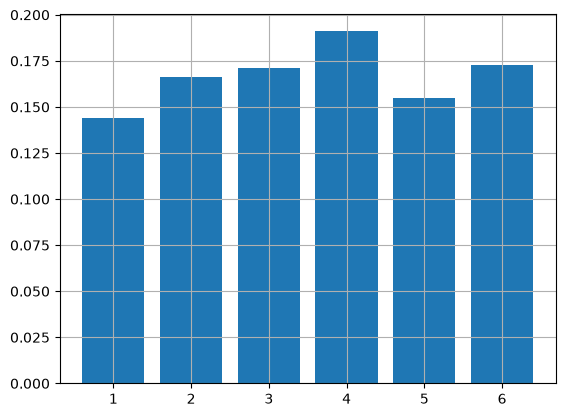

In [18]:
# 一様分布
# さいころを１０００回振ってみる
calc_steps = 1000

# 1-6のデータの中から、１０００回の抽出を実施
dice_rolls = np.random.choice(dice_data, calc_steps)

# それぞれの数字がどれくらいの割合で抽出されたか計算
prob_data = np.array([])
for i in range(1, 7):
    p = len(dice_rolls[dice_rolls == i]) / calc_steps
    prob_data = np.append(prob_data, len(dice_rolls[dice_rolls == i]) / calc_steps)

plt.bar(dice_data, prob_data)
plt.grid(True)

In [19]:
# ベルヌーイ分布
# 0:head(表), 1:tail(裏)と数える
# サンプル数を８とした
prob_be_data = np.array([])
coin_data = np.array([0, 0, 0, 0, 0, 1, 1, 1])

# uniqueで一意な値を抽出
for i in np.unique(coin_data):
    p = len(coin_data[coin_data == i]) / len(coin_data)
    print(i, 'が出る確率', p)
    prob_be_data = np.append(prob_be_data, p)

0 が出る確率 0.625
1 が出る確率 0.375


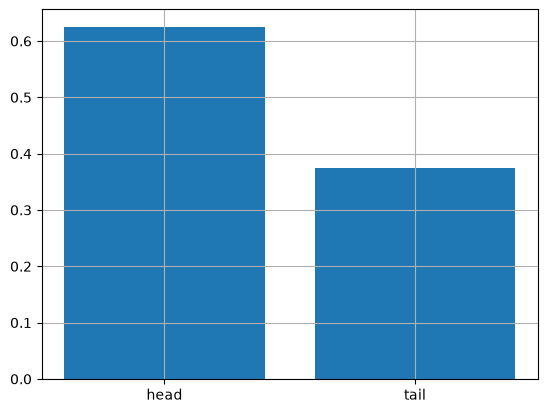

In [20]:
plt.bar([0, 1], prob_be_data, align='center')
plt.xticks([0, 1], ['head', 'tail'])
plt.grid(True)

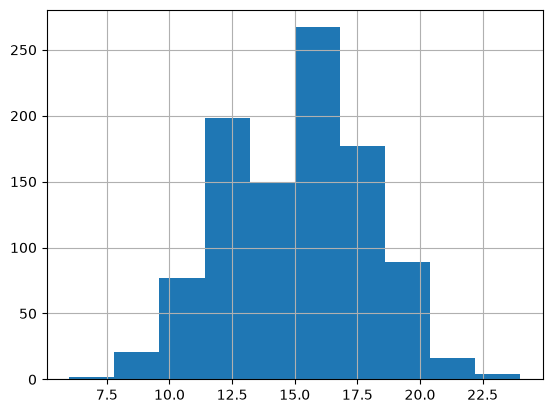

In [21]:
# 二項分布
np.random.seed(0)
x = np.random.binomial(30, 0.5, 1000)
plt.hist(x)
plt.grid(True)

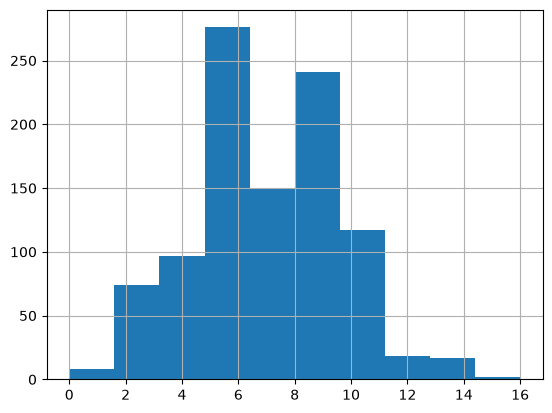

In [22]:
# ポアソン分布
x = np.random.poisson(7, 1000)
plt.hist(x)
plt.grid(True)

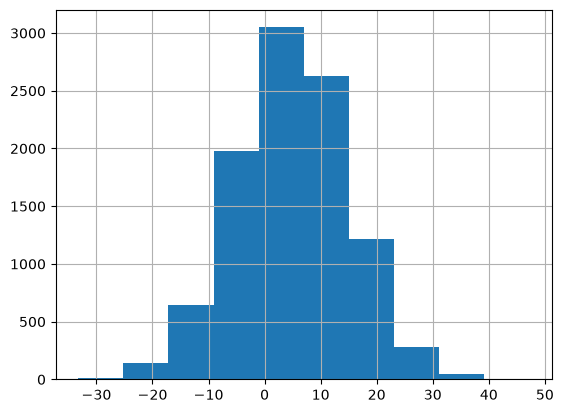

In [23]:
# 正規分布
# np.random.normal(平均、 標準偏差、 サンプル数)
x = np.random.normal(5, 10, 10000)
plt.hist(x)
plt.grid(True)

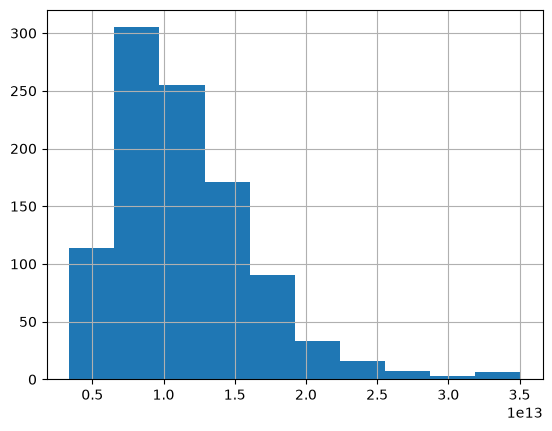

In [24]:
# 対数正規分布
x = np.random.lognormal(30, 0.4, 1000)
plt.hist(x)
plt.grid(True)

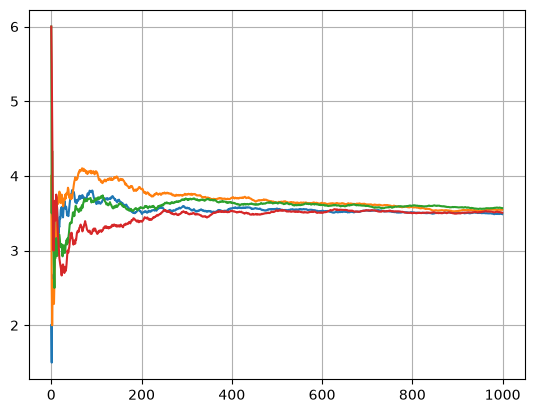

In [25]:
# 大数の法則
# 計算回数
calc_times = 1000
# さいころ
sample_array = np.array([1, 2, 3, 4, 5, 6])
number_cut = np.arange(1, calc_times + 1)

# 4つのパスを生成
for i in range(4):
    p = np.random.choice(sample_array, calc_times).cumsum()
    plt.plot(p / number_cut)
    plt.grid(True)

In [30]:
# 中心極限定理
def function_central_theory(N):

    sample_array = np.array([1, 2, 3, 4, 5, 6])
    number_cunt = np.arange(1, N + 1) * 1.0

    mean_array = ([])

    for i in range(1000):
        cum_variables = np.random.choice(sample_array, N).cumsum()*1.0
        mean_array = np.append(mean_array, cum_variables[N - 1] / N)

    plt.hist(mean_array)
    plt.grid(True)

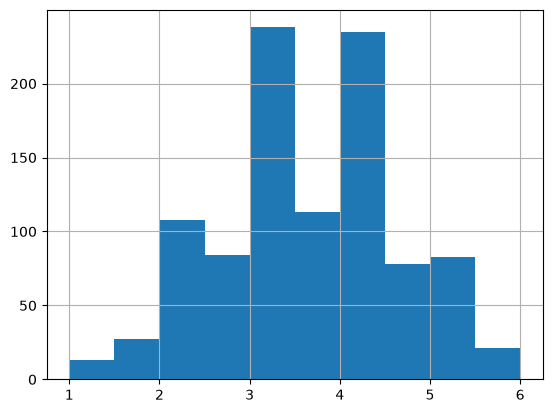

In [31]:
# N = 3
function_central_theory(3)

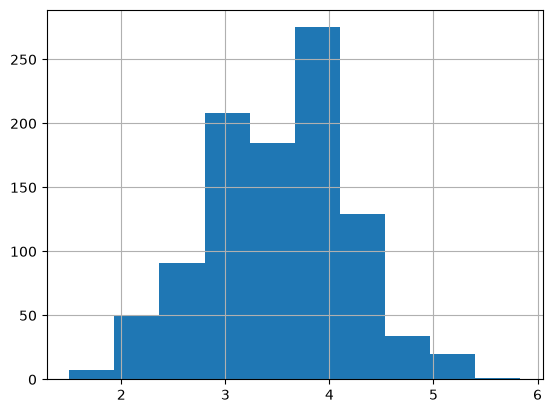

In [32]:
# N = 6
function_central_theory(6)

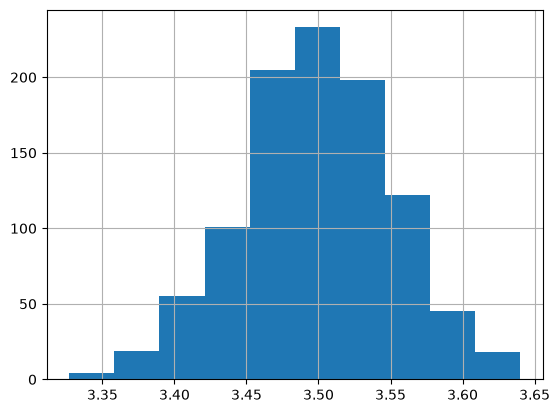

In [33]:
# N = 10^3
function_central_theory(10 ** 3)

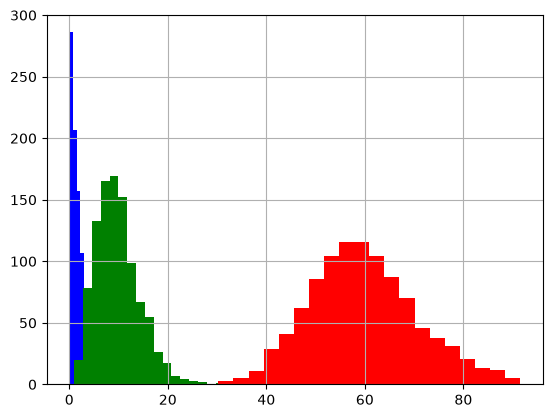

In [34]:
# カイ二乗分布
# 自由度２、１０、60に従うカイ二乗分布が生成する乱数のヒストグラム
for df, c in zip([2, 10, 60], "bgr"):
    x = np.random.chisquare(df, 1000)
    plt.hist(x, 20, color=c)
    plt.grid(True)

In [38]:
student_data_math = pd.read_csv('chap3/student+performance/student/student-mat.csv', sep=';')
student_data_por = pd.read_csv('chap3/student+performance/student/student-por.csv', sep=';')

student_data_merge = pd.merge(student_data_math, student_data_por,
                              on=['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason',
                                  'nursery', 'internet'],
                              suffixes=['_math', '_por'])

print('G1数学の成績平均:', student_data_merge.G1_math.mean())
print('G1ポルトガル語の成績平均:', student_data_merge.G1_por.mean())

G1数学の成績平均: 10.861256544502618
G1ポルトガル語の成績平均: 12.112565445026178


In [39]:
from scipy import stats
t, p = stats.ttest_rel(student_data_merge.G1_math, student_data_merge.G1_por)
print('p値:', p)

p値: 1.6536555217101e-16


In [40]:
# 総合問題
# absences に差があるか
print('数学の欠席数平均:', student_data_merge.absences_math.mean())
print('ポルトガル語の欠席数平均:', student_data_merge.absences_por.mean())

t, p = stats.ttest_rel(student_data_merge.absences_math, student_data_merge.absences_por)
print('p値:', p)

数学の欠席数平均: 5.319371727748691
ポルトガル語の欠席数平均: 3.6727748691099475
p値: 2.344165688838404e-06


有意差１パーセント未満で差があると結論付ける